In [1]:
import os
import shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter
import seaborn as sns
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
source_dir = "C:\\Users\\totil\\OneDrive\\Documents\\GitHub\\Clasificaci-n-Frambuesas\\Data_img\\dataset"
output_dir = "C:\\Users\\totil\\OneDrive\\Documents\\GitHub\\Clasificaci-n-Frambuesas\\Data_img\\Mixed dataset"

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

for cls in classes:
   class_path = os.path.join(source_dir, cls)
   images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
   
   train_imgs, temp_imgs = train_test_split(
       images, 
       test_size=(val_ratio + test_ratio), 
       random_state=42
   )
   
   relative_test_size = test_ratio / (val_ratio + test_ratio)
   val_imgs, test_imgs = train_test_split(
       temp_imgs, 
       test_size=relative_test_size, 
       random_state=42
   )
   
   splits = {
       'train': train_imgs, 
       'val': val_imgs, 
       'test': test_imgs
   }
   
   for split_name, split_imgs in splits.items():
       destination_path = os.path.join(output_dir, split_name, cls)
       os.makedirs(destination_path, exist_ok=True)
       
       for img in split_imgs:
           shutil.copy(os.path.join(class_path, img), os.path.join(destination_path, img))
           
   print(f"Class '{cls}': Total {len(images)} images -> Split into {len(train_imgs)} train, {len(val_imgs)} val, {len(test_imgs)} test.")

print("\nData splitting complete! All data preserved.")

Class 'Other': Total 3902 images -> Split into 2731 train, 585 val, 586 test.
Class 'Raspberry': Total 833 images -> Split into 583 train, 125 val, 125 test.

Data splitting complete! All data preserved.


In [ ]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    'C:\\Users\\totil\\OneDrive\\Documents\\GitHub\\Clasificaci-n-Frambuesas\\Data_img\\Mixed dataset\\train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'C:\\Users\\totil\\OneDrive\\Documents\\GitHub\\Clasificaci-n-Frambuesas\\Data_img\\Mixed dataset\\val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    r'C:\Users\totil\OneDrive\Documents\GitHub\Clasificaci-n-Frambuesas\Data_img\Mixed dataset\test',
    image_size=IMG_SIZE, # Make sure this matches your model (e.g., (224, 224) or (100, 100))
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False # Keep false for test data so your evaluation metrics align perfectly
)

all_labels = np.concatenate([y.numpy() for x, y in train_ds], axis=0).flatten()
counter = Counter(all_labels)
total_samples = len(all_labels)

class_weight = {
    0: total_samples / (2.0 * counter[0.0]),
    1: total_samples / (2.0 * counter[1.0])
}

print(f"Calculated Class Weights to balance the loss function: {class_weight}")


Found 3314 files belonging to 2 classes.
Found 710 files belonging to 2 classes.
Found 711 files belonging to 2 classes.
Calculated Class Weights to balance the loss function: {0: 0.606737458806298, 1: 2.8421955403087478}


In [4]:
model= models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.summary()
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 98, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 49, 49, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 47, 47, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 23, 23, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 21, 21, 64)        36928     
                                                                 
 flatten (Flatten)           (None, 28224)             0

In [ ]:
history = model.fit(train_ds, validation_data=val_ds, epochs=15, class_weight=class_weight)

test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

Epoch 1/15
104/104 [==============================] - 12s 67ms/step - loss: 7.7418 - accuracy: 0.9028 - val_loss: 0.0089 - val_accuracy: 0.9972
Epoch 2/15
104/104 [==============================] - 4s 35ms/step - loss: 0.0220 - accuracy: 0.9937 - val_loss: 3.5714e-05 - val_accuracy: 1.0000
Epoch 3/15
104/104 [==============================] - 3s 32ms/step - loss: 2.2969e-05 - accuracy: 1.0000 - val_loss: 2.9894e-05 - val_accuracy: 1.0000
Epoch 4/15
104/104 [==============================] - 4s 32ms/step - loss: 1.9315e-05 - accuracy: 1.0000 - val_loss: 2.6551e-05 - val_accuracy: 1.0000
Epoch 5/15
104/104 [==============================] - 4s 34ms/step - loss: 1.6646e-05 - accuracy: 1.0000 - val_loss: 2.2258e-05 - val_accuracy: 1.0000
Epoch 6/15
104/104 [==============================] - 4s 33ms/step - loss: 1.4333e-05 - accuracy: 1.0000 - val_loss: 1.9579e-05 - val_accuracy: 1.0000
Epoch 7/15
104/104 [==============================] - 4s 33ms/step - loss: 1.2553e-05 - accuracy: 1.0000 

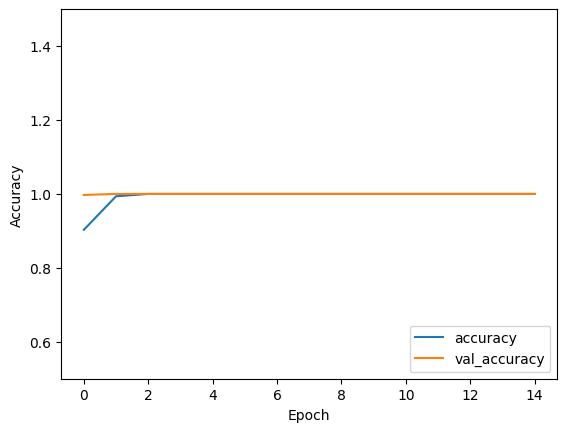

In [6]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1.5])
plt.legend(loc='lower right')
plt.show()

23/23 [==============================] - 0s 9ms/step
True labels array size: 711
Predicted labels array size: 711


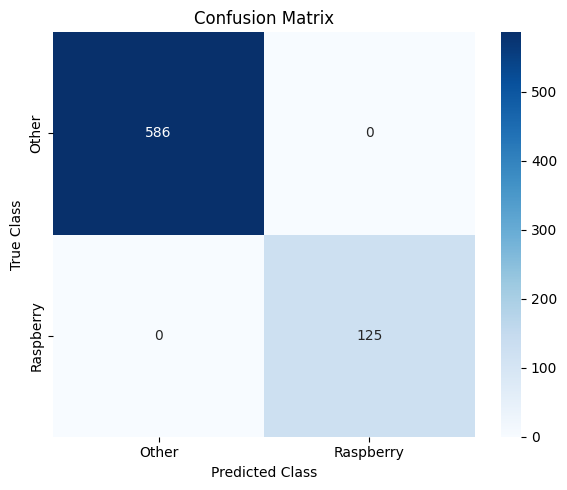


Classification Report:

              precision    recall  f1-score   support

       Other       1.00      1.00      1.00       586
   Raspberry       1.00      1.00      1.00       125

    accuracy                           1.00       711
   macro avg       1.00      1.00      1.00       711
weighted avg       1.00      1.00      1.00       711



In [ ]:
test_images = []
true_labels = []

for images, labels in test_ds:
    test_images.append(images.numpy())
    true_labels.append(labels.numpy())

# Convert lists of batches into single unified numpy arrays
test_images = np.concatenate(test_images, axis=0)
true_labels = np.concatenate(true_labels, axis=0).flatten().astype(int)

# 2. Predict using the static numpy array of images instead of the dataset object
predictions = model.predict(test_images)

# 3. Convert probabilities to binary classes (0 or 1)
predicted_labels = (predictions > 0.5).astype(int).flatten()

# --- INSTANT VERIFICATION ---
print(f"True labels array size: {true_labels.shape[0]}")
print(f"Predicted labels array size: {predicted_labels.shape[0]}")

# 4. Generate the confusion matrix data
cm = confusion_matrix(true_labels, predicted_labels)

# 5. Get class names
class_names = test_ds.class_names 

# 6. Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True,          
    fmt='d',             
    cmap='Blues',        
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

# 7. Print classification report
print("\nClassification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_names))